In [75]:
#!/usr/bin/env python3
# coding: utf-8
"""
rho_vs_w_experiment.py  数据保存在rho_vs_w_experiment

研究稳态感染密度 rho 关于断开超边比例 w 的变化，
对比不同超边活跃度阈值 Theta_del（以及随机删除作为对照）。

输出：
 - out_dir/rho_vs_w_perrun.csv : 每次重复的原始记录（每行一个运行）
 - out_dir/rho_vs_w_summary.csv: 汇总（按 theta_del、w 分组），包含 mean_rho, std_rho, mean_fdel
"""

import os
import time
import math
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

# -------------------- 超图生成器 --------------------
def generate_hypergraph_H_n_m_3(n, kappa, seed=None, batch_size=3000):
    """
    生成 3-uniform hypergraph (m,3)。
    参数：
      n: 节点数
      kappa: 平均度（平均每个节点参与的超边「半度」乘以 d）
      seed: 随机种子（可复现）
    返回：
      hyperedges: ndarray shape (m,3)
    """
    rng = np.random.RandomState(seed) if seed is not None else np.random
    d = 3
    m = int(round(n * kappa / d))
    max_possible = math.comb(n, d)
    if m > max_possible:
        raise ValueError("m > C(n,3)")
    nodes = np.arange(n)
    edges_set = set()
    # 批量采样候选三元组以加速
    while len(edges_set) < m:
        tris = rng.choice(nodes, size=(batch_size, d), replace=True)
        for i in range(tris.shape[0]):
            row = tris[i]
            # 若重复或包含重复节点则重新采样该行
            if len(np.unique(row)) < d:
                row = rng.choice(nodes, size=(d,), replace=False)
            tris[i] = np.sort(row)
        for row in tris:
            if len(edges_set) >= m:
                break
            edges_set.add(tuple(row.tolist()))
    hyperedges = np.array(list(edges_set), dtype=int)
    hyperedges.sort(axis=1)
    return hyperedges

# -------------------- MMCA 带删除策略的实现 --------------------
class MMCAWithDeletion:
    def __init__(self, hyperedges, n):
        """
        初始化：仅建立索引结构供后续迭代使用
        """
        self.hyperedges = np.asarray(hyperedges, dtype=int)
        self.n = n
        self.m = self.hyperedges.shape[0]
        # 三端点数组（向量化便利）
        self.edge_i = self.hyperedges[:,0].copy()
        self.edge_j = self.hyperedges[:,1].copy()
        self.edge_k = self.hyperedges[:,2].copy()
        # node -> list of (edge_index, pos)
        self.node_edge_pos = [[] for _ in range(n)]
        for ei in range(self.m):
            a,b,c = self.hyperedges[ei]
            self.node_edge_pos[a].append((ei,0))
            self.node_edge_pos[b].append((ei,1))
            self.node_edge_pos[c].append((ei,2))

    def _compute_edge_products(self, p):
        """
        返回三组向量：对于每条超边，取除当前位置外两节点的 p 的乘积，便于后续计算
        """
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        return (p_j * p_k, p_i * p_k, p_i * p_j)

    def run_mmca_with_deletion(self,
                               beta_d, mu, eta, gamma,
                               deletion_type='threshold',
                               theta_del=None,              # 阈值删除使用
                               w=0.0,                       # 最大删除比例（0..1）
                               init_frac=0.01,
                               tol=1e-8, max_iter=2000,
                               rng_seed=None,
                               verbose=False,
                               threshold_delete_selection='closest_to_threshold'):
        """
        运行 MMCA 并按给定策略删除超边（删除后永久不再参与传播/Theta置0）
        参数说明：
          deletion_type: 'threshold' 或 'random'
            - 'threshold': 动态阈值删除（当 Theta_next < theta_del 且预算尚未用完时删除）
            - 'random': 在初始时随机删除 w 比例的边（一次性）
          theta_del: 阈值（仅当 deletion_type == 'threshold' 时使用）
          w: 最大删除比例（0..1），删除预算 = floor(w * m)
          threshold_delete_selection:
            - 'closest_to_threshold' : 在候选（Theta_next < theta_del）中优先删除 Theta 值 **较大** 的（最接近阈值）
            - 'lowest_theta' : 优先删除 Theta 值 **最小** 的
            - 'random' : 在候选中随机删除
        返回 dict，包含 rho_final、f_del、rho_hist、theta_mean_hist 等
        """
        rng = np.random.RandomState(rng_seed) if rng_seed is not None else np.random

        n = self.n; m = self.m
        p = np.full(n, init_frac, dtype=float)
        Theta = np.ones(m, dtype=float)

        # 预算：允许删除的最大条数（整数）
        deletion_budget = int(math.floor(float(w) * m))
        # 防止把所有边删光（保留最少1条边以维持网络），但当 m==1 时不做额外处理
        if deletion_budget >= m:
            if m > 1:
                deletion_budget = m - 1
            else:
                deletion_budget = 0

        # active掩码，True 表示该边仍参与传播；False 表示被删除
        active = np.ones(m, dtype=bool)
        deleted_count = 0

        # 如果使用 random 策略：一开始就随机删除 deletion_budget 条边（一次性）
        if deletion_type == 'random' and deletion_budget > 0:
            del_idx = rng.choice(m, size=deletion_budget, replace=False)
            active[del_idx] = False
            Theta[~active] = 0.0
            deleted_count = int((~active).sum())

        rho_hist = []
        theta_mean_hist = []
        iters = 0

        # 主迭代
        for it in range(max_iter):
            rho_hist.append(p.mean())
            theta_mean_hist.append(Theta[active].mean() if active.any() else 0.0)

            # 计算每条边中“其它两个节点”的 p 乘积（向量化）
            prod_pos0, prod_pos1, prod_pos2 = self._compute_edge_products(p)

            # 逐节点计算 Q_i（跳过 inactive 边）
            Q = np.ones(n, dtype=float)
            for node in range(n):
                prod_val = 1.0
                for (ei, pos) in self.node_edge_pos[node]:
                    if not active[ei]:
                        continue
                    if pos == 0:
                        oth = prod_pos0[ei]
                    elif pos == 1:
                        oth = prod_pos1[ei]
                    else:
                        oth = prod_pos2[ei]
                    prod_val *= (1.0 - Theta[ei] * beta_d * oth)
                Q[node] = prod_val

            # MMCA p 更新
            p_next = (1.0 - p) * (1.0 - Q) + (1.0 - mu) * p

            # Theta 更新（只对 active 边生效）
            if active.any():
                p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
                Phi = p_i * p_j * p_k
                Theta_next = Theta * (1.0 - eta * Phi) + gamma * (1.0 - Theta)
                Theta_next = np.clip(Theta_next, 0.0, 1.0)
                Theta_next[~active] = 0.0
            else:
                Theta_next = Theta.copy()

            # 若为阈值删除策略，尝试在候选中删除（但受 deletion_budget 限制）
            if deletion_type == 'threshold' and (theta_del is not None) and deletion_budget > 0 and deleted_count < deletion_budget:
                # 候选集合：Theta_next < theta_del 且仍 active
                cand = np.where((Theta_next < theta_del) & active)[0]
                if cand.size > 0:
                    remaining = deletion_budget - deleted_count
                    if cand.size <= remaining:
                        to_delete = cand
                    else:
                        if threshold_delete_selection == 'random':
                            to_delete = rng.choice(cand, size=remaining, replace=False)
                        elif threshold_delete_selection == 'lowest_theta':
                            # 按 Theta_next 升序（从最小开始删除）
                            order = np.argsort(Theta_next[cand])  # indices into cand
                            to_delete = cand[order[:remaining]]
                        elif threshold_delete_selection == 'closest_to_threshold':
                            # 按 Theta_next 降序（取最接近阈值的那些，即 Theta 最大的）
                            order = np.argsort(-Theta_next[cand])  # descending
                            to_delete = cand[order[:remaining]]
                        else:
                            # fallback
                            to_delete = rng.choice(cand, size=remaining, replace=False)

                    # 执行删除（永久）
                    active[to_delete] = False
                    Theta_next[to_delete] = 0.0
                    deleted_count += to_delete.size

            # 提交更新并检查收敛
            dp = np.max(np.abs(p_next - p))
            dTheta = np.max(np.abs(Theta_next - Theta)) if active.any() else 0.0
            p = p_next
            Theta = Theta_next
            iters = it + 1

            if dp < tol and dTheta < tol:
                break

        rho_final = float(p.mean())
        num_deleted = int((~active).sum())
        f_del = float(num_deleted) / float(m)

        return {
            'rho_final': rho_final,
            'iters': iters,
            'num_deleted': num_deleted,
            'f_del': f_del,
            'rho_hist': np.array(rho_hist),
            'theta_mean_hist': np.array(theta_mean_hist),
            'active_mask': active.copy()
        }

# -------------------- 并行单任务包装器 --------------------
def run_single_simulation(params):
    """
    params: tuple containing
      (deletion_type, theta_del, w, run_index, n, kappa, beta, mu, eta, gamma,
       init_frac, tol, max_iter, seed_base, threshold_delete_selection)
    """
    (deletion_type, theta_del, w, r, n, kappa, beta, mu, eta, gamma,
     init_frac, tol, max_iter, seed_base, threshold_delete_selection) = params

    gen_seed = None if seed_base is None else (seed_base + r)
    hyperedges = generate_hypergraph_H_n_m_3(n=n, kappa=kappa, seed=gen_seed)
    model = MMCAWithDeletion(hyperedges, n)

    res = model.run_mmca_with_deletion(
        beta_d=beta, mu=mu, eta=eta, gamma=gamma,
        deletion_type=deletion_type, theta_del=theta_del, w=w,
        init_frac=init_frac, tol=tol, max_iter=max_iter,
        rng_seed=gen_seed,
        threshold_delete_selection=threshold_delete_selection
    )

    # 返回一行记录
    return {
        'deletion_type': deletion_type,
        'theta_del': theta_del if deletion_type == 'threshold' else -1.0,
        'w_target': w if deletion_type == 'random' else float('nan'),
        'w_budget': w,
        'run': r,
        'rho_final': res['rho_final'],
        'f_del': res['f_del'],
        'num_deleted': res['num_deleted'],
        'iters': res['iters']
    }

# -------------------- 并行驱动函数 --------------------
def run_rho_vs_w_experiment(n, kappa,
                            beta, mu, eta, gamma,
                            theta_del_list, w_list,
                            R=20, init_frac=0.01,
                            tol=1e-8, max_iter=2000,
                            seed_base=12345,
                            out_dir="rho_vs_w_experiment",
                            n_jobs=1,
                            threshold_delete_selection='closest_to_threshold'):
    """
    并行扫描：对每个 theta_del，在 w_list 上做重复实验 R 次（每次生成新超图）
    返回 df_results（每次运行一行）以及 summary（按 theta_del, w 汇总）
    """
    os.makedirs(out_dir, exist_ok=True)

    # 构建参数组合
    param_combinations = []
    # 阈值删除（threshold）: 我们把 w 当作“最大允许删除比例（预算）”
    for theta_del in theta_del_list:
        for w in w_list:
            for r in range(R):
                params = ('threshold', float(theta_del), float(w), r,
                          n, kappa, beta, mu, eta, gamma,
                          init_frac, tol, max_iter, seed_base, threshold_delete_selection)
                param_combinations.append(params)
    # 随机删除对照（random）：我们也把 w_list 作为预算（一次性随机删除预算比例）
    for w in w_list:
        for r in range(R):
            params = ('random', float('nan'), float(w), r,
                      n, kappa, beta, mu, eta, gamma,
                      init_frac, tol, max_iter, seed_base, threshold_delete_selection)
            param_combinations.append(params)

    total_tasks = len(param_combinations)
    print(f"[INFO] 总任务数: {total_tasks}  (theta_del points {len(theta_del_list)}, w points {len(w_list)}, R={R})")
    print(f"[INFO] 并行任务数 n_jobs={n_jobs}")

    # 并行执行
    t0 = time.time()
    results = Parallel(n_jobs=n_jobs, verbose=1)(
        delayed(run_single_simulation)(params) for params in param_combinations
    )
    elapsed = time.time() - t0
    print(f"[INFO] 并行任务完成，耗时 {elapsed:.1f}s")

    # 收集为 DataFrame
    df_runs = pd.DataFrame(results)
    # 保存每次运行原始记录
    runs_fn = os.path.join(out_dir, "rho_vs_w_perrun.csv")
    df_runs.to_csv(runs_fn, index=False, float_format="%.6f")
    print(f"[INFO] 已保存每次运行数据 -> {runs_fn}")

    # 汇总：按 (deletion_type, theta_del, w_budget) 分组
    # 注意 random 策略的 theta_del 为 NaN（分组时保留）
    summary = df_runs.groupby(['deletion_type', 'theta_del', 'w_budget']).agg(
        mean_rho=('rho_final', 'mean'),
        std_rho=('rho_final', 'std'),
        mean_fdel=('f_del', 'mean'),
        std_fdel=('f_del', 'std'),
        mean_deleted=('num_deleted', 'mean')
    ).reset_index().sort_values(['deletion_type', 'theta_del', 'w_budget'])
    
    summary['theta_label'] = summary['theta_del'].apply(lambda x: 'random' if x == -1 else f"{x:.2f}")

    summary_fn = os.path.join(out_dir, "rho_vs_w_summary.csv")
    summary.to_csv(summary_fn, index=False, float_format="%.6f")
    print(f"[INFO] 已保存汇总数据 -> {summary_fn}")

    return df_runs, summary




In [76]:
# -------------------- 脚本参数（请按需修改） --------------------
# 网络 / 模型参数
n = 1500
kappa = 9.0

# 固定传播参数（我们对 beta 做一次固定值的实验；若需扫描 beta 可在外层再做循环）
beta = 0.35
mu = 0.1
eta = 0.6
gamma = 0.03

# 实验参数：你关心的 theta_del 值和 w 网格
theta_del_list = [0.2, 0.4, 0.6]      # 三条阈值曲线
# w_list = np.linspace(0.0, 1.0, 41)    # 删除比例

w_list = np.concatenate([
    np.arange(0.0, 0.2, 0.05),
    np.arange(0.2, 0.75, 0.05),
    np.arange(0.75, 0.95, 0.005),
    np.arange(0.95, 1.0, 0.05),
])

# 并行 / 重复设置
R = 50                # 每个参数组合重复次数
init_frac = 0.3
tol = 1e-8
max_iter = 1500
seed_base = 12345
out_dir = "rho_vs_w_experiment"
n_jobs = 18            # 并行任务数（根据你机器实际CPU调整）
threshold_delete_selection = 'closest_to_threshold'  # 你需要的策略

# -------------------- 运行 --------------------
if __name__ == "__main__":
    print("===== 开始 rho vs w 实验 =====")
    t0_all = time.time()
    df_runs, summary = run_rho_vs_w_experiment(
        n=n, kappa=kappa,
        beta=beta, mu=mu, eta=eta, gamma=gamma,
        theta_del_list=theta_del_list, w_list=w_list,
        R=R, init_frac=init_frac,
        tol=tol, max_iter=max_iter,
        seed_base=seed_base,
        out_dir=out_dir,
        n_jobs=n_jobs,
        threshold_delete_selection=threshold_delete_selection
    )
    print("===== 全部完成，耗时 {:.1f}s =====".format(time.time() - t0_all))
    # print("简单预览 summary：")
    # print(summary.head(20))

===== 开始 rho vs w 实验 =====
[INFO] 总任务数: 11400  (theta_del points 3, w points 57, R=50)
[INFO] 并行任务数 n_jobs=18


[Parallel(n_jobs=18)]: Using backend LokyBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done  14 tasks      | elapsed:    1.2s
[Parallel(n_jobs=18)]: Done 164 tasks      | elapsed:   11.6s
[Parallel(n_jobs=18)]: Done 414 tasks      | elapsed:   30.6s
[Parallel(n_jobs=18)]: Done 764 tasks      | elapsed:  1.6min
[Parallel(n_jobs=18)]: Done 1214 tasks      | elapsed:  4.1min
[Parallel(n_jobs=18)]: Done 1764 tasks      | elapsed:  5.4min
[Parallel(n_jobs=18)]: Done 2414 tasks      | elapsed:  6.4min
[Parallel(n_jobs=18)]: Done 3164 tasks      | elapsed:  7.8min
[Parallel(n_jobs=18)]: Done 4014 tasks      | elapsed: 13.1min
[Parallel(n_jobs=18)]: Done 4964 tasks      | elapsed: 17.5min
[Parallel(n_jobs=18)]: Done 6014 tasks      | elapsed: 19.6min
[Parallel(n_jobs=18)]: Done 7164 tasks      | elapsed: 26.5min
[Parallel(n_jobs=18)]: Done 8414 tasks      | elapsed: 31.5min
[Parallel(n_jobs=18)]: Done 9764 tasks      | elapsed: 35.9min
[Parallel(n_jobs=18)]: Done 11214 tasks      

[INFO] 并行任务完成，耗时 2410.7s
[INFO] 已保存每次运行数据 -> rho_vs_w_experiment\rho_vs_w_perrun.csv
[INFO] 已保存汇总数据 -> rho_vs_w_experiment\rho_vs_w_summary.csv
===== 全部完成，耗时 2410.8s =====


[Parallel(n_jobs=18)]: Done 11400 out of 11400 | elapsed: 40.2min finished


Saved figure -> rho_vs_w_experiment\rho_vs_w_plot.png


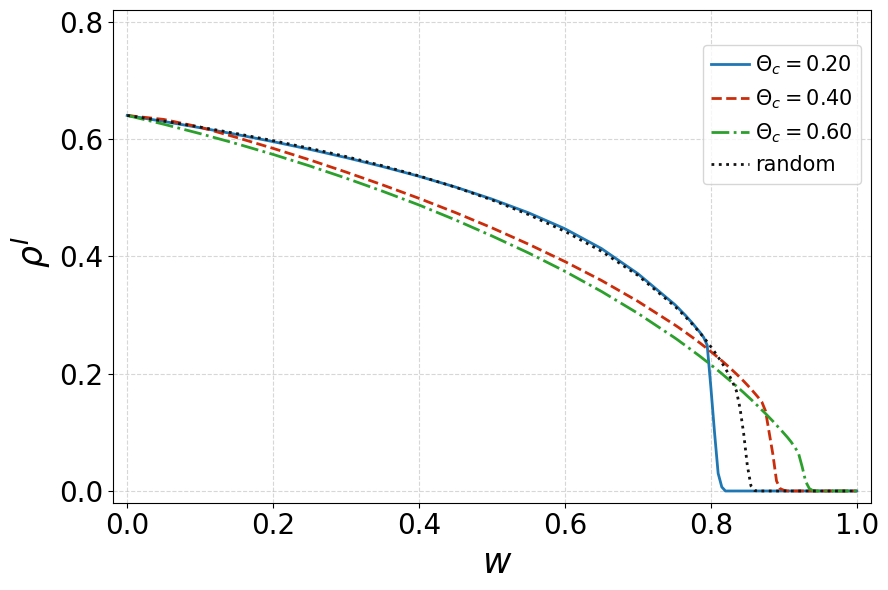

In [77]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
plot_rho_vs_w_simple.py

从 `rho_vs_w_experiment/rho_vs_w_summary.csv` 读取汇总数据，
绘制 ρ* (mean_rho) vs w_budget 的曲线，比较不同的 theta_del（Θ）与 random 对照。

输出:
  rho_vs_w_experiment/rho_vs_w_plot.png
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 配置 ----------
OUT_DIR = "rho_vs_w_experiment"            # 与运行脚本相同的输出目录
SUMMARY_FN = os.path.join(OUT_DIR, "rho_vs_w_summary.csv")
FIG_FN = os.path.join(OUT_DIR, "rho_vs_w_plot.png")

# 颜色和样式（可按需改）
colors = ['#1f77b4', "#cb2d0a", '#2ca02c', "#151313",]
markers = ['o', 's', '^', 'D', 'v', 'P']
linestyles = ['-', '--', '-.', ':']

# ---------- 读取数据 ----------
if not os.path.exists(SUMMARY_FN):
    raise FileNotFoundError(f"Summary file not found: {SUMMARY_FN}")

df = pd.read_csv(SUMMARY_FN)

# 兼容：有的脚本把 w 列名叫 'w' 或 'w_budget'，优先使用 w_budget
if 'w_budget' not in df.columns and 'w' in df.columns:
    df = df.rename(columns={'w': 'w_budget'})

# 检查必须列
required = {'deletion_type', 'theta_del', 'w_budget', 'mean_rho', 'std_rho'}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns in summary CSV: {missing}")

# ---------- 生成用于绘图的标签列 ----------
# 如果 deletion_type 是 'random' 则标记为 'random'，否则用 Θ=xx 标签（保留两位小数）
def make_label(row):
    if str(row['deletion_type']).lower() == 'random':
        return 'random'
    # 若 theta_del 为 NaN（安全起见），也标为 random
    try:
        if pd.isna(row['theta_del']):
            return 'random'
    except:
        pass
    return fr"$\Theta_c={float(row['theta_del']):.2f}$"

df['theta_label'] = df.apply(make_label, axis=1)

# ---------- 为每个 theta_label 绘制曲线 ----------
plt.figure(figsize=(9,6))

labels = sorted(df['theta_label'].unique(), key=lambda x: (x=='random', x))  # 把 'random' 放最后
for i, label in enumerate(labels):
    sub = df[df['theta_label'] == label].copy()
    if sub.empty:
        continue
    # 确保按 w_budget 升序
    sub = sub.sort_values('w_budget')
    x = sub['w_budget'].to_numpy()
    y = sub['mean_rho'].to_numpy()
    # std 列可能全为 NaN（比如重复数=1），用 0 代替
    if 'std_rho' in sub.columns:
        yerr = sub['std_rho'].fillna(0.0).to_numpy()
    else:
        yerr = np.zeros_like(y)

    color = colors[i % len(colors)]
    marker = markers[i % len(markers)]
    linestyle = linestyles[i % len(linestyles)]
    # plt.plot(x, y, label=label, color=color, marker=marker, linewidth=2, markersize=6)
    plt.plot(x, y, label=label, color=color, linestyle=linestyle, linewidth=2, )
    # 绘制阴影带（均值 ± std）
    # if np.any(yerr > 0):
    #     plt.fill_between(x, y - yerr, y + yerr, alpha=alpha_fill, color=color)

# ---------- 图形美化 ----------
plt.xlabel(r" $w$ ", fontsize=25)
plt.ylabel(r" $ρ^I$ ", fontsize=25)
# plt.title("Steady-state prevalence ρ* vs edge removal fraction w", fontsize=14)
plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 0.82)
plt.xticks(np.linspace(0,1,6), fontsize=20)
plt.yticks(np.linspace(0,0.8,5), fontsize=20)
plt.grid(alpha=0.5, linestyle='--', linewidth=0.8)

legend = plt.legend(
    loc='upper right',
    bbox_to_anchor=(1, 0.95),
    fontsize='15',
    handletextpad=0.3,    # 图标与文本的间距
    #columnspacing=1,      # 列间距（多列时有效）
    borderpad=0.4,          # 图例内边距
    # ncol=2,              # 分两列
    handlelength=1.8,    # 统一图标宽度
    columnspacing=0.5,     # 缩小列间距（默认2.0）
)
plt.tight_layout()

# ---------- 保存并显示 ----------
os.makedirs(OUT_DIR, exist_ok=True)
plt.savefig(FIG_FN, dpi=300, bbox_inches='tight')
print(f"Saved figure -> {FIG_FN}")
plt.show()
